Detected Base Delay (Ticks): -4140657244.0
        frame.time_relative  queuing_delay
1                  0.006494   0.000000e+00
2                  0.019277   8.000000e+00
3                  0.024609   1.000000e+00
4                  0.024741   1.000000e+00
5                  0.036965   1.300000e+01
...                     ...            ...
194252            48.646413   2.298671e+09
194253            48.646496   2.298671e+09
194254            48.646704   2.298671e+09
194255            48.661568   2.298671e+09
194256            48.662345   2.298671e+09

[194208 rows x 2 columns]


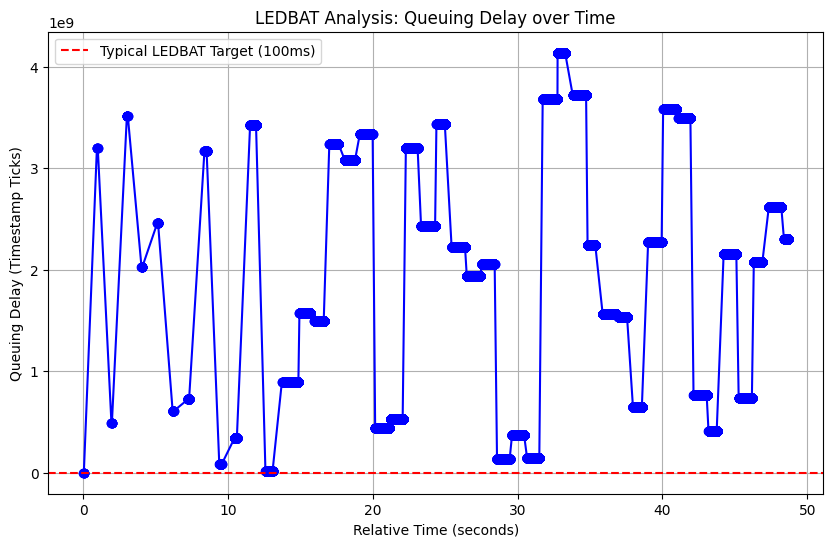

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

filename = rf"receiver\results\attack_a1_50ms\rcv_wnd.csv"

# 讀取資料
df = pd.read_csv(filename)

def analyze_ledbat(df):
    # 1. 篩選掉握手階段 (tsecr 為 0 的封包無法計算延遲)
    df_clean = df[df['tcp.options.timestamp.tsecr'] > 0].copy()
    
    # 2. 計算單向延遲測量值 (OWD)
    # 公式：本地收到的時戳 (tsval) - 遠端發送時紀錄的時戳 (tsecr)
    # 註：這包含兩端時鐘偏移，因此絕對值無意義，重點在於「變化量」
    df_clean['owd_raw'] = df_clean['tcp.options.timestamp.tsval'] - df_clean['tcp.options.timestamp.tsecr']
    
    # 3. 計算 Base Delay (基準延遲)
    # LEDBAT 維護一個滑動視窗內的最小值作為 Base Delay
    base_delay = df_clean['owd_raw'].min()
    
    # 4. 計算 Queuing Delay (排隊延遲)
    # 這是 LEDBAT 擁塞控制演算法的輸入值：queuing_delay = current_delay - base_delay
    df_clean['queuing_delay'] = df_clean['owd_raw'] - base_delay
    
    # 5. 輸出統計與結果
    print(f"Detected Base Delay (Ticks): {base_delay}")
    print(df_clean[['frame.time_relative', 'queuing_delay']])
    
    # 6. 繪圖
    plt.figure(figsize=(10, 6))
    plt.plot(df_clean['frame.time_relative'], df_clean['queuing_delay'], marker='o', linestyle='-', color='b')
    
    # 畫出典型的 LEDBAT Target (假設時鐘頻率為 1ms/tick, Target = 100ms)
    plt.axhline(y=100, color='r', linestyle='--', label='Typical LEDBAT Target (100ms)')
    
    plt.title('LEDBAT Analysis: Queuing Delay over Time')
    plt.xlabel('Relative Time (seconds)')
    plt.ylabel('Queuing Delay (Timestamp Ticks)')
    plt.legend()
    plt.grid(True)


analyze_ledbat(df)